# 0. Computer Vision Libraries used
* `torchvison` - base domain library for computer vision
* `torchvision.datasets` - gets datasets and loading fns for computer vision
* `torchvision.models`
* `torchvision.transforms` - fns for manipulating the visual data(in this case images) to tensors or numpy arrays such that the ML model can understand
* `torch.utils.data.DataLoader` - creates python iterable over the dataset(such that the data can be loaded back)
* `torch.utils.data.Dataset` - base dataset class in PyTorch. Can be used to create custom dataset too


In [ ]:
# Importing the neccessary libraries
import torch
from torch import nn # Base class for all neutral networks

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt # For visualizing the model's prediction, etc.


# 1. Creating a dataset
We will use FashionMNIST dataset from `torchvision.datasets`. This dataset contains visual images of clothing items etc.

In [ ]:
# Setting up the training data

train_data = datasets.FashionMNIST(
    root= "data", # Like where to download the data? / Setting directory for the dataset to download
    train= True, # So within the dataset it is already separated that specific data is for the train dataset while the other are for test dataset. train = True makes the dataset give those train dataset
    download= True,
    transform= torchvision.transforms.ToTensor(), # Transforms the PIL image and returns something the ML can understand. Used for input transformation
    target_transform= None # This transforms the label/output
)

# Setting up the testing data

test_data = datasets.FashionMNIST(
    root= "data",
    train = False,
    download= True,
    transform= torchvision.transforms.ToTensor(), # Instead of this we can also write ToTensor() also.
    target_transform= None
)

In [ ]:
# Let's check the length of the training and testing dataset
print(f'Length of the training data -> {len(train_data)}')
print(f'Length of the testing data -> {len(test_data)}')

Length of the training data -> 60000
Length of the testing data -> 10000


In [ ]:
# Let's see the class names in the data we have
class_names = train_data.classes
len(class_names) # So we have data that can be classified into 10 classes

10

In [ ]:
# Let's see the first sample from the data
image, label = train_data[0]
# So image is a tensor of some PIL image in the dataset
print(f'Shape of the image -> {image.shape}')
print(f'Class to which the image belong is {class_names[label]}')
# label gives a specific number which can be paired with the name of the classes in the class_names

Shape of the image -> torch.Size([1, 28, 28])
Class to which the image belong is Ankle boot


In [ ]:
train_data.class_to_idx # For label = 9 is associated with Ankle Boot

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

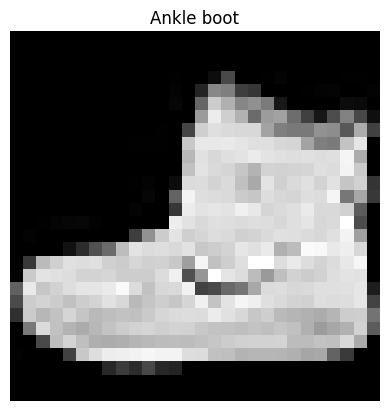

In [ ]:
# Visulizing the image of the ankle boot we got
plt.imshow(image.squeeze(), cmap='gray'); # Shape of image is 1*28*28 after squeeze it becomes 28*28
plt.title(class_names[label]);
plt.axis(False);

# 2. Prepare DataLoader
Right now, our data is in form of PyTorch's dataset. DataLoader turns our data into Python iterable. More specifically, it turns our data into batchs(or mini batchs)

So why we need to turn data into batchs?
1. When we work with large amount of data for its computation we need lot of memory on the hardware we are using, in order to reduce the load on the hardware instead of running the entire data at once, we can separate them into batchs and compute for more efficieny.
2. It gives the neutral network more chance to update its gradient per epoch.

In [ ]:
# Setting the batch size
BATCH_SIZE = 32

# Turning the data into dataloader
from torch.utils.data import DataLoader

# Setting the train dataloader
train_dataloader = DataLoader(
    dataset= train_data,
    batch_size= BATCH_SIZE,
    shuffle = True # Shuffles the order of the data in the dataset and then sends to the dataloader
)

# Setting the test dataloader
test_dataloader = DataLoader(
    dataset= test_data,
    batch_size= BATCH_SIZE,
    shuffle= False
)

In [ ]:
# Let's see how many batchs of data are there in the dataloader
print(f'Train DataLoader has {len(train_dataloader)} batchs of {BATCH_SIZE}')
print(f'Test DataLoader has {len(test_dataloader)} batchs of {BATCH_SIZE}')


Train DataLoader has 1875 batchs of 32
Test DataLoader has 313 batchs of 32


# 3. Let's create a base model

## 3.1 How the `Flatten()` works?

In [ ]:
# Create a flatten layer(IMP!!)
flatten_layer = nn.Flatten()

# We already have our first sample i.e., image

# Let's get output by passing the sample into the flatten layer
output = flatten_layer(image)

print(f'The shape of image before flattening -> {image.shape}')
print(f'The shape of image after flattening -> {output.shape}')
#As we can see the last two dims 28 and 28 just multiplied and became 784.
#So the fn just combined them both and made a single long tensor




The shape of image before flattening -> torch.Size([1, 28, 28])
The shape of image after flattening -> torch.Size([1, 784])


In [ ]:
# Creating the base model
class FashionMNISTModelV0(nn.Module):
  def __init__(self,
               input_shape:int, # input_shape:int states that the input shape should be int
               hidden_units:int,
               output_shape:int): # This is basically equal to no.of classes(in this case 10)
    super().__init__()
    # Whatever goes through Sequential goes layer-by-layer
    self.layer_stack = nn.Sequential(
        nn.Flatten(), # Whatever data comes in first gets flattened bz the linear activation fn can accept only 1-D tensor
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),# There is a rule that if two linear activation fns are line-by-line then the out_features of one linear fn = in_features of the other
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape)
    )

  # Whatever class sub-classing the nn.Module must over-write the forward fn
  def forward(self, x):
    return self.layer_stack(x)


In [ ]:
# Setting a seed for reproducibility of the data
torch.manual_seed(40)

# Creating an instance of the model class
model_0 = FashionMNISTModelV0(
    input_shape=784,# After flatten 28*28 will be 784 only
    hidden_units=10,# Can be anything(hyperparameter)
    output_shape=len(class_names)# 10 in this case
)

## 3.2 Picking up loss function, optimizer and evaluation metrics
* Loss function - Since we're working with multi-class classification, our loss function will be `CrossEntropyLoss()`.
* Optimizer - One of the best optimizer for this case `torch.optim.SGD()`**(stochastic gradient descent)**.
* Evaluation Metric - As we are working with classification problem we will choose **accuracy** as evaluation metric.

In [ ]:
# Installing a reusable code from internet for accuracy calculation
import requests
from pathlib import Path

# Downloading the helper function from internet
if Path('helper_functions.py').is_file():
  print('Helper function already exists.')
else:
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open('helper_functions.py','wb') as f:
    f.write(request.content) # Basic file handling


Helper function already exists.


In [ ]:
# Importing the accuracy fn
from helper_functions import accuracy_fn

# Setting up loss fn & optimizer
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1) # lr = learning rate -> how fast the algo learns

## 3.3 Creating a function to track the time of the experiments

Two main things we can track,
1. Model's performance(such as loss and accuracy values).
2. Time taken for the model to run.

In [ ]:
from timeit import default_timer as timer
def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
  total_time = end - start
  print(f'Train time on {device} : {total_time:.3f} seconds')
  return total_time


In [ ]:
# How this works?
start_time = timer()
# some code....
end_time = timer()
print_train_time(start=start_time,
                 end=end_time,
                 device='cpu')
# The time is very less bz there is no code running in b/w the start and end time object

Train time on cpu : 0.000 seconds


5.173299996386049e-05

In [ ]:
# Setting the device agnostic code(IMP!!)
device = 'cuda' if torch.cuda.is_available() else 'cpu'


## 3.4 Functionizing the train and test loop.
**The optimizer will update the parameter once per batch rather than updating once per epoch.**

How the training and testing is done,
1. Loop through epochs
2. Loop through the training batchs, perform training steps, calculate the train loss per batch
3. Loop through the testing batchs, perform testing steps, calculate the test loss per batch

### 3.4.1 Functionizing the training loop
Function -> `train_step()`

In [ ]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
  train_loss, train_acc = 0, 0
  ### Training
  # Train mode
  model.train()

  # Adding a loop to loop through the batchs
  # X, y is nothing but the image, label (or) feature, label
  for batch, (X, y) in enumerate(data_loader):
    # Put the data in the target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass of the data
    y_pred = model(X)

    # 2. Calculate the loss & accuracy
    loss = loss_fn(y_pred,
                          y)
    train_loss += loss
    train_acc += accuracy_fn(y_true=y,
                             y_pred=y_pred.argmax(dim=1))
    # We do argmax(dim=1) bz the accuracy fn want its input as label but y_pred is logit, to logit -> pred prob -> pred labels we use argmax(dim=1)

    # 3. Setting the optimizer to zero gradient(bz in each loop the gradient accumalates inorder to avoid it we are setting to zero again)
    optimizer.zero_grad()

    # 4. Backpropagation
    loss.backward()

    # 5. Gradient Descent
    optimizer.step()


  # Divide the train_loss/train_acc by the length of dataloader to get the avg per batch
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  train_loss_count.append(train_loss)

  print(f'\nTrain Loss: {train_loss:.5f} | Train Acc" {train_acc:.2f}%')

### 3.4.2 Functionizing the testing loop
Function -> `test_step()`

In [ ]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
  test_loss, test_acc = 0, 0
  ### Testing
  model.eval()
  with torch.inference_mode():
    # Adding a loop to loop through the batchs
    for X, y in data_loader:
      # Put the data in the target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      test_pred = model(X)

      # 2. Calculate the loss and accuracy
      test_loss += loss_fn(test_pred,
                           y)
      test_acc += accuracy_fn(y_true=y,
                              y_pred=test_pred.argmax(dim=1)) # logit -> pred prob -> pred label


    # Finding the avg
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    test_loss_count.append(test_loss)

    print(f'Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%')



# 4. Training the model
**We will use tqdm module also from python used to show the progress bar**



In [ ]:
# Import the tqdm
from tqdm.auto import tqdm

# Setting the seed for reproducibility
torch.manual_seed(40)

# Start the timer
train_time_start_model_0 = timer() # Ofcourse on cpu

# Set the no.of epochs
epochs = 4
epoch_count = []
train_loss_count = []
test_loss_count = []

for epoch in tqdm(range(epochs)):
  epoch_count.append(epoch)
  print(f'Epoch: {epoch}\n---------')
  train_step(model=model_0,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(model=model_0,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)

# End the timer
train_time_end_model_0 = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_model_0,
                                            end=train_time_end_model_0,
                                            device=device)

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 0
---------

Train Loss: 0.59804 | Train Acc" 78.57%
Test Loss: 0.51811 | Test Acc: 81.48%
Epoch: 1
---------

Train Loss: 0.47924 | Train Acc" 83.14%
Test Loss: 0.50687 | Test Acc: 81.83%
Epoch: 2
---------

Train Loss: 0.45513 | Train Acc" 83.92%
Test Loss: 0.49100 | Test Acc: 82.95%
Epoch: 3
---------

Train Loss: 0.44422 | Train Acc" 84.54%
Test Loss: 0.46907 | Test Acc: 83.46%
Train time on cpu : 40.447 seconds


# 5. Making function for evaluation of the model

In [ ]:
torch.manual_seed(40)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      # Put the data in the target device
      X, y = X.to(device), y.to(device)

      # Making predictions
      model = model.to(device)
      y_pred = model(X)

      # Accumulating the loss and accuracy
      loss += loss_fn(y_pred,
                      y)
      acc += accuracy_fn(y_true=y,
                         y_pred=y_pred.argmax(dim=1))

    # Finding the avg loss and acc
    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name":model.__class__.__name__,
          "model_loss":loss.item(),
          "model_acc":acc}


In [ ]:
results_model_0 = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)
results_model_0

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.46906808018684387,
 'model_acc': 83.4564696485623}

# 6. Model_1: Building a model with Convolutional Neutral Network

**CNN's are known for their capability of finding patterns in images**

## 6.1 Hyperparamters in CNN's
* **kernel** -> It is like a filtering window. Say suppose our input image is of shape 5x5 and size of our kernel is 2(which means 2x2). Then this 2x2 square box travels through the image covering certain pixels and give output accordingly. If the kernel size was 5 then only one output is given.
* **stride** -> How much pixels then the kernel move each time?
* **padding** -> The extra layer set out of the image.It is necessary when the kernel extends out of the image box.

**Function**
* `**MaxPool2d()**` -> It reduces the spatial dimensions(height and width) of feature map by sliding the kernel across the input and outputting the max value of the region covered by the kernel at current.
Say we have input image of shape 16x16 with kernel size = 4 and stride = 2 then the kernel can only go to four regions, then if from each region one maximum is found then the final output will have 4 values/something like that...

So basically doing this compresses the image and the ML algo trains on these compressed versions


In [ ]:
from torch.nn.modules.pooling import MaxPool2d
from torch.nn.modules.conv import Conv2d
# Creating a Convolutional Neutral Network
class FashionMNISTModelV1(nn.Module):
  # The model replicates the architecture of the TinyVGG
  def __init__(self,
               input_shape:int,
               hidden_units:int,
               output_shape:int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, # color channels(in our case it is = 1)
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(), # Non-linear activation function
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    # Like till now we have learnt the patterns in the images but to classify the labels with the patterns learnt. We need a classifier layer
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,# In this case it is 10*7*7 has after flatten we can clearly see that we get 490 as input. But we have calculate for other cases
                  out_features=output_shape)
    )
  def forward(self, x):
    #print(f'{x.shape}\n-------')
    x = self.conv_block_1(x)
    #print(f'{x.shape}\n-------')
    x = self.conv_block_2(x)
    #print(f'{x.shape}\n-------')
    x = self.classifier(x)
    #print(f'{x.shape}\n-------')
    return x

In [ ]:
torch.manual_seed(40)

# Creating an instance of the model class
model_1 = FashionMNISTModelV1(input_shape=1,
                              hidden_units=10,
                              output_shape=len(class_names)).to(device)

In [ ]:
# Importing the accuracy fn
from helper_functions import accuracy_fn

# Setting up loss fn & optimizer
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1) # lr = learning rate -> how fast the algo learns

# 7. Training the new version of the model


In [ ]:
# Import the tqdm
from tqdm.auto import tqdm

torch.manual_seed(40)

train_time_start_model_1 = timer()

epochs = 4
epoch_count = []
train_loss_count = []
test_loss_count = []

for epoch in tqdm(range(epochs)):
  epoch_count.append(epoch)
  print(f'Epoch: {epoch}\n---------')
  train_step(model=model_1,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             accuracy_fn=accuracy_fn,
             optimizer=optimizer,
             device=device)
  test_step(model=model_1,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)

train_time_end_model_1 = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_model_1,
                                            end=train_time_end_model_1,
                                            device=device)

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch: 0
---------

Train Loss: 0.57925 | Train Acc" 78.90%
Test Loss: 0.42281 | Test Acc: 84.68%
Epoch: 1
---------

Train Loss: 0.34777 | Train Acc" 87.61%
Test Loss: 0.34320 | Test Acc: 87.41%
Epoch: 2
---------

Train Loss: 0.30952 | Train Acc" 88.83%
Test Loss: 0.33024 | Test Acc: 88.28%
Epoch: 3
---------

Train Loss: 0.28973 | Train Acc" 89.46%
Test Loss: 0.30624 | Test Acc: 89.26%
Train time on cpu : 230.622 seconds


In [ ]:
results_model_1 = eval_model(model=model_1,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)
results_model_1

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.3062438368797302,
 'model_acc': 89.25718849840256}

In [ ]:
# Creating a table to compare model_0 and model_1
import pandas as pd
compare_table = pd.DataFrame([results_model_0,
                              results_model_1])
compare_table["training_time"] = [total_train_time_model_0,
                                  total_train_time_model_1]
compare_table

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.469068,83.456470,40.447259
1,FashionMNISTModelV1,0.306244,89.257188,230.622466


In [ ]:
len(epoch_count), len(train_loss_count), len(test_loss_count)

(4, 4, 4)

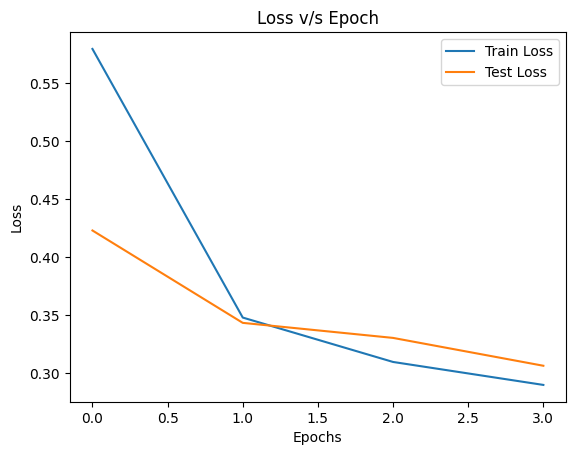

In [ ]:
# Plotting the Loss v/s epochs curve
import numpy as np
plt.plot(epoch_count,np.array(torch.tensor(train_loss_count).numpy()), label="Train Loss")
plt.plot(epoch_count,np.array(torch.tensor(test_loss_count).numpy()), label="Test Loss")
plt.title("Loss v/s Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend();

# 8. Saving the model weights and bias

In [ ]:
import pickle
# ------Save------
# We always save the state_dict of the model to save the weight+bias
with open('weights_v1.pkl','wb') as f:
  pickle.dump(model_1.state_dict(), f) # This stores the state_dicts nothing but parameters of the model i.e., weights and bias

# Confirmation msg
print("Model weights have been sucessfully saved")

# ------Load------
# Loading back the state_dicts of the model_1 to a model with same architecture
loaded_model_1 = FashionMNISTModelV1(input_shape=1,
                                     hidden_units=10,
                                     output_shape=len(class_names)).to(device)

with open('weights_v1.pkl','rb') as f:
  loaded_model_1.load_state_dict(pickle.load(f))

loaded_model_1.eval()
print("Model weights have been loaded!")


Model weights have been sucessfully saved
Model weights have been loaded!


In [ ]:
# Finding the true labels
true_label = []
for image, label in test_data:
  true_label.append(label)
true_label[:5]

[9, 2, 1, 1, 6]

In [ ]:
# Running predictions on the entire test set
loaded_model_1.eval() # Using loaded model to check if it works or not
all_preds = []
all_ids = []

sample_id = 0

with torch.inference_mode():
  for X, y in test_dataloader:
    X = X.to(device)

    # Getting the logits from the model through samples then converting them to labels using argmax fn
    preds = loaded_model_1(X).argmax(dim=1)

    all_preds.extend(preds.cpu().tolist())
    all_ids.extend(range(sample_id, sample_id+len(preds))) # This helps to give consecutive no.s for elements in each batch and maintains the order
    sample_id += len(preds)

submission_df = pd.DataFrame({
    'id': all_ids,
    'predicted_label': all_preds,
    'predicted_class_name': [class_names[pred] for pred in all_preds],
    'true_class_name': [class_names[true] for true in true_label]
})

# Time to convert the dataframe to csv file
submission_df.to_csv('submission.csv', index=False)
print(submission_df.head()) # To print the first 5 rows
print(f'Total no.of predictions -> {len(submission_df)}') # Should be 10000


   id  predicted_label predicted_class_name true_class_name
0   0                9           Ankle boot      Ankle boot
1   1                2             Pullover        Pullover
2   2                1              Trouser         Trouser
3   3                1              Trouser         Trouser
4   4                6                Shirt           Shirt
Total no.of predictions -> 10000


In [ ]:
submission_df

,id,predicted_label,predicted_class_name,true_class_name
0,0,9,Ankle boot,Ankle boot
1,1,2,Pullover,Pullover
2,2,1,Trouser,Trouser
3,3,1,Trouser,Trouser
4,4,6,Shirt,Shirt
...,...,...,...,...
9995,9995,9,Ankle boot,Ankle boot
9996,9996,1,Trouser,Trouser
9997,9997,8,Bag,Bag
9998,9998,1,Trouser,Trouser
